# CTR Structure-Factor and DWBA Benchmark

Benchmark CTR calculations for a representative test crystal. The notebook first compares the original NumPy structure-factor path with the optional C++ and Numba acceleration backends, then measures the complete uncached DWBA calculation against the fastest available kinematic backend.

The first accelerated call may include setup or compilation overhead, so the benchmark does an explicit warmup before recording timings. The reported timings are runtime-only measurements after warmup.

The accelerated CTR kernels are intentionally single-threaded at this level. This benchmark measures the benefit from fused loops, low temporary-array allocation, and compiler optimization without adding thread parallelism inside the structure-factor kernels. Form-factor caching is disabled throughout the timed sections so that repeated input arrays do not hide calculation cost.


## Setup

Start Jupyter from the `benchmarks/` directory and run this notebook there. The benchmark imports the installed `orgui` package from the active Python environment. The benchmark uses the copied CTR regression fixture in `benchmarks/fixtures/0V12_calculated.xpr`.


## Backend Selection

CTR structure-factor calculations default to C++ when the extension is available and run the explicit NumPy structure-factor path otherwise. Numba is not imported automatically unless selected. To select the active process-global backend before importing `CTRuc`, set the shared backend variable:

```bash
ORGUI_ACCEL_BACKEND=cpp python my_ctr_script.py
ORGUI_ACCEL_BACKEND=numba python my_ctr_script.py
ORGUI_ACCEL_BACKEND=numpy python my_ctr_script.py
```

The same selection can be changed inside a Python process:

```python
from orgui.datautils.xrayutils import CTRuc

CTRuc.set_accel_backend("cpp")
CTRuc.set_accel_backend("numba")
CTRuc.set_accel_backend("numpy")  # disable acceleration
```

`CTRuc.set_accel_backend("numba")` raises `ValueError` if the optional Numba backend cannot be imported. See **Acceleration Backends** in the main documentation for the ROI and CTR selector summary.


In [1]:
from pathlib import Path
import statistics
import time

import numpy as np


BENCHMARK_DIR = Path.cwd().resolve()
FIXTURE_CANDIDATES = (
    BENCHMARK_DIR / "fixtures",
    BENCHMARK_DIR.parents[2] / "benchmarks" / "fixtures",
)
FIXTURE_DIR = next((path for path in FIXTURE_CANDIDATES if path.is_dir()), None)
if FIXTURE_DIR is None:
    raise FileNotFoundError(
        "Could not find benchmark fixtures. Run from benchmarks/ or execute "
        "this notebook from doc/source/benchmarks/."
    )
XPR_PATH = FIXTURE_DIR / "0V12_calculated.xpr"

if (BENCHMARK_DIR / "orgui").is_dir():
    raise RuntimeError(
        "Notebook is running from the repository root. Start Jupyter from "
        "benchmarks/ to benchmark the installed package."
    )

print(f"Benchmark directory: {BENCHMARK_DIR}")
print(f"Fixture:             {XPR_PATH}")


Benchmark directory: C:\Users\timof\Documents\repos\orGUI\doc\source\benchmarks
Fixture:             C:\Users\timof\Documents\repos\orGUI\benchmarks\fixtures\0V12_calculated.xpr


In [2]:
!hostname


CTRsurfacePC


In [3]:
from orgui import __version__, get_build_config
print("orGUI version", __version__)
print(get_build_config())


orGUI version 1.5.1.dev279+g699e69cd9.d20260909
{'native_optimization': False, 'target_cpu': 'generic', 'allowed_instruction_set': [], 'native_arguments': '', 'cpp_compiler_id': 'msvc', 'cpp_compiler_version': '19.51.36256', 'host_system': 'windows', 'host_cpu_family': 'x86_64', 'host_cpu': 'x86_64', 'available': True}


In [4]:
from orgui.datautils import util
from orgui.datautils.xrayutils import CTRcalc, CTRuc


AVAILABLE_BACKENDS = ["numpy"]
if CTRuc.HAS_CPP_ACCEL:
    AVAILABLE_BACKENDS.append("cpp")
if CTRuc.ctr_numba_accel_available():
    AVAILABLE_BACKENDS.append("numba")

print(f"Default CTR acceleration backend: {CTRuc.CTR_ACCEL_BACKEND}")
print(f"Available CTR acceleration backends: {AVAILABLE_BACKENDS}")


Default CTR acceleration backend: cpp
Available CTR acceleration backends: ['numpy', 'cpp']


## Benchmark Helpers

`CTRuc.CTR_ACCEL_BACKEND` selects the active implementation. Use `CTRuc.set_accel_backend("cpp" | "numba" | "numpy")` to compare the direct C++ extension, Numba kernels, and original NumPy implementation.


In [5]:
def set_backend(backend):
    CTRuc.set_accel_backend(backend)


def disable_form_factor_cache():
    if not CTRuc.HAS_CPP_ACCEL:
        return None
    budget = CTRuc.form_factor_cache_stats()["budget_bytes"]
    CTRuc.clear_form_factor_cache()
    CTRuc.set_form_factor_cache_budget(0)
    return budget


def restore_form_factor_cache(budget):
    if budget is None:
        return
    CTRuc.clear_form_factor_cache()
    CTRuc.set_form_factor_cache_budget(budget)


def load_crystal():
    xtal = CTRcalc.SXRDCrystal.fromFile(XPR_PATH)
    pt100 = CTRcalc.UnitCell(
        [3.9242, 3.9242, 3.9242],
        [90.0, 90.0, 90.0],
    )
    xtal.setGlobalReferenceUnitCell(
        pt100,
        util.z_rotation(np.deg2rad(45.0)),
    )
    return xtal


def make_rod(n_points):
    l_values = np.ascontiguousarray(
        np.linspace(0.05, 7.0, n_points),
        dtype=np.float64,
    )
    zeros = np.zeros_like(l_values)
    return zeros, zeros, l_values


def time_call(func, repeats=7, warmups=1):
    for _ in range(warmups):
        func()

    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        func()
        timings.append(time.perf_counter() - start)

    return {
        "min_s": min(timings),
        "median_s": statistics.median(timings),
        "mean_s": statistics.mean(timings),
        "repeats": repeats,
    }


def format_seconds(value):
    if value < 1e-3:
        return f"{value * 1e6:8.1f} us"
    if value < 1:
        return f"{value * 1e3:8.2f} ms"
    return f"{value:8.3f} s"



## Warmup and Correctness Check

The accelerated and non-accelerated paths should produce the same complex amplitudes within normal floating-point tolerance before any timing results are trusted.


In [6]:
xtal = load_crystal()
h, k, l = make_rod(2_000)

set_backend("numpy")
numpy_uc = xtal.uc_bulk.F_uc(h, k, l)
numpy_xtal = xtal.F(h, k, l)

for backend in AVAILABLE_BACKENDS:
    if backend == "numpy":
        continue
    set_backend(backend)
    backend_uc = xtal.uc_bulk.F_uc(h, k, l)
    backend_xtal = xtal.F(h, k, l)
    np.testing.assert_allclose(backend_uc, numpy_uc, rtol=1e-12, atol=1e-12)
    np.testing.assert_allclose(backend_xtal, numpy_xtal, rtol=1e-10, atol=1e-10)

print("Available accelerated backends match NumPy for UnitCell.F_uc and SXRDCrystal.F")


Available accelerated backends match NumPy for UnitCell.F_uc and SXRDCrystal.F


## Uncached Structure-Factor Backends

The table measures direct structure-factor evaluations for increasing CTR rod lengths. The process-global form-factor cache budget is set to zero around every benchmark, including warmup, and restored afterward. The result therefore compares calculation backends rather than cache-hit performance.


In [7]:
def benchmark_structure_factor(n_points, repeats=7):
    xtal = load_crystal()
    h, k, l = make_rod(n_points)

    def run_unitcell(backend):
        set_backend(backend)
        return lambda: xtal.uc_bulk.F_uc(h, k, l)

    def run_crystal(backend):
        set_backend(backend)
        return lambda: xtal.F(h, k, l)

    original_budget = disable_form_factor_cache()
    try:
        rows = []
        for label, factory in (
            ("UnitCell.F_uc", run_unitcell),
            ("SXRDCrystal.F", run_crystal),
        ):
            stats = {
                backend: time_call(factory(backend), repeats=repeats)
                for backend in AVAILABLE_BACKENDS
            }
            row = {
                "benchmark": label,
                "points": n_points,
            }
            for backend, backend_stats in stats.items():
                row[f"{backend}_median_s"] = backend_stats["median_s"]
                row[f"{backend}_min_s"] = backend_stats["min_s"]
            for backend in AVAILABLE_BACKENDS:
                if backend == "numpy":
                    continue
                row[f"{backend}_speedup"] = (
                    row["numpy_median_s"] / row[f"{backend}_median_s"]
                )
            rows.append(row)
    finally:
        restore_form_factor_cache(original_budget)
    return rows


results = []
for n_points in (200, 2_000, 4_000):
    results.extend(benchmark_structure_factor(n_points))

header = f"{'benchmark':<18} {'points':>8}"
for backend in AVAILABLE_BACKENDS:
    header += f" {backend + ' median':>15}"
for backend in AVAILABLE_BACKENDS:
    if backend != "numpy":
        header += f" {backend + ' speedup':>14}"
print(header)
for row in results:
    line = f"{row['benchmark']:<18} {row['points']:>8}"
    for backend in AVAILABLE_BACKENDS:
        line += f" {format_seconds(row[f'{backend}_median_s']):>15}"
    for backend in AVAILABLE_BACKENDS:
        if backend != "numpy":
            line += f" {row[f'{backend}_speedup']:>13.2f}x"
    print(line)


benchmark            points    numpy median      cpp median    cpp speedup
UnitCell.F_uc           200         68.7 us         14.8 us          4.64x
SXRDCrystal.F           200        208.0 us         56.7 us          3.67x
UnitCell.F_uc          2000        196.6 us         86.6 us          2.27x
SXRDCrystal.F          2000        608.7 us        333.8 us          1.82x
UnitCell.F_uc          4000        337.3 us        168.6 us          2.00x
SXRDCrystal.F          4000         1.03 ms        645.4 us          1.59x


## Benchmark Results

The plot compares uncached structure-factor backend medians.


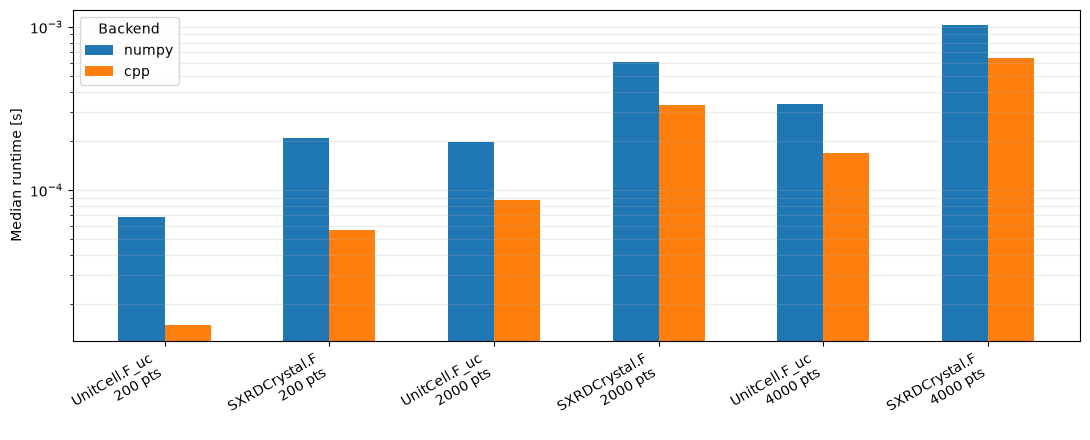

In [8]:
from matplotlib import pyplot as plt

labels = [f"{row['benchmark']}\n{row['points']} pts" for row in results]
x = np.arange(len(labels))
width = min(0.8 / len(AVAILABLE_BACKENDS), 0.28)
offsets = (np.arange(len(AVAILABLE_BACKENDS)) - (len(AVAILABLE_BACKENDS) - 1) / 2) * width

fig, ax = plt.subplots(figsize=(11, 4.5))
for offset, backend in zip(offsets, AVAILABLE_BACKENDS):
    ax.bar(
        x + offset,
        [row[f"{backend}_median_s"] for row in results],
        width,
        label=backend,
    )

ax.set_ylabel("Median runtime [s]")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.legend(title="Backend")
ax.grid(axis="y", which="both", alpha=0.25)
fig.tight_layout()


## Uncached DWBA versus Kinematic Calculation

This section measures the complete same-polarization DWBA calculation against `SXRDCrystal.F` for the same Pt(100) crystal and `(0, 0, L)` points. The kinematic baseline uses the fastest available backend in the order C++, Numba, NumPy.

The form-factor cache remains disabled for both paths. Before every timed DWBA call, `DWBAState.clear_cache()` removes retained geometry, optical-reference, field, and preparation entries; `cache=False` also prevents the new preparation from being retained. Consequently the DWBA median includes preparation, optical-field solving, atom packing, the four-channel native matrix-element kernel, and result assembly. The warmup only absorbs one-time import or JIT startup and does not provide cached scientific inputs to a measured call. This intentionally measures the full cold-call penalty of DWBA rather than a fit loop with reusable geometry.


Kinematic baseline: cpp
  points       kinematic       DWBA s->s   DWBA slowdown
     200         58.3 us         5.87 ms         100.68x
    2000        338.0 us        43.27 ms         128.01x
    4000        652.1 us       132.80 ms         203.65x


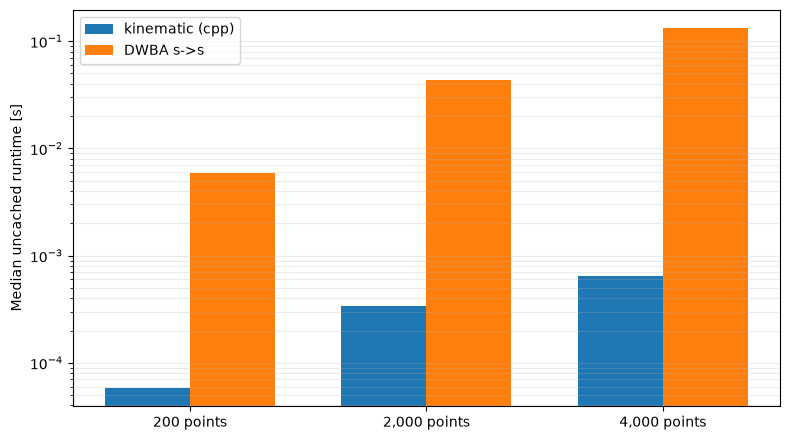

In [9]:
KINEMATIC_BACKEND = next(
    backend for backend in ("cpp", "numba", "numpy")
    if backend in AVAILABLE_BACKENDS
)


def benchmark_dwba_slowdown(n_points, repeats=5):
    xtal = load_crystal()
    xtal.dwba.set_ctr_geometry(equal_angles=True)
    h, k, l = make_rod(n_points)
    set_backend(KINEMATIC_BACKEND)

    def run_kinematic():
        return xtal.F(h, k, l)

    def run_dwba():
        xtal.dwba.clear_cache()
        return xtal.dwba.evaluate(
            h,
            k,
            l,
            polarization_i="s",
            polarization_f="s",
            cache=False,
        ).F_h

    original_budget = disable_form_factor_cache()
    try:
        kinematic = time_call(run_kinematic, repeats=repeats)
        dwba = time_call(run_dwba, repeats=repeats)
    finally:
        xtal.dwba.clear_cache()
        restore_form_factor_cache(original_budget)

    return {
        "points": n_points,
        "kinematic_median_s": kinematic["median_s"],
        "dwba_median_s": dwba["median_s"],
        "dwba_slowdown": dwba["median_s"] / kinematic["median_s"],
    }


dwba_results = [
    benchmark_dwba_slowdown(n_points)
    for n_points in (200, 2_000, 4_000)
]

print(f"Kinematic baseline: {KINEMATIC_BACKEND}")
print(f"{'points':>8} {'kinematic':>15} {'DWBA s->s':>15} {'DWBA slowdown':>15}")
for row in dwba_results:
    print(
        f"{row['points']:8d} "
        f"{format_seconds(row['kinematic_median_s']):>15} "
        f"{format_seconds(row['dwba_median_s']):>15} "
        f"{row['dwba_slowdown']:14.2f}x"
    )

labels = [f"{row['points']:,} points" for row in dwba_results]
x = np.arange(len(labels))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    x - width / 2,
    [row["kinematic_median_s"] for row in dwba_results],
    width,
    label=f"kinematic ({KINEMATIC_BACKEND})",
)
ax.bar(
    x + width / 2,
    [row["dwba_median_s"] for row in dwba_results],
    width,
    label="DWBA s->s",
)
ax.set_ylabel("Median uncached runtime [s]")
ax.set_yscale("log")
ax.set_xticks(x, labels)
ax.legend()
ax.grid(axis="y", which="both", alpha=0.25)
fig.tight_layout()
